# ***RFC vs GBM***

**Task** : Multiclass classification (Easy=0 / Normal=1 / Hard=2)  
**Input** : 8 fitur agregat riwayat sesi pemain  
**Output** : `GBM.pkl` yang kompatibel langsung dengan `Sudoku.py`

**Strategi seleksi:** RFC dan GBM dibandingkan secara *head-to-head*.  
Model terbaik disimpan berdasarkan:  
1. *Validation Balanced Accuracy*  
2. Kualitas kalibrasi probabilitas  
3. *Overfitting gap* (*post-tuning learning curve*)

## 1. Setup & Imports


In [1]:
import numpy as np
import pandas as pd
import json, os, pickle, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve,
    validation_curve,
    cross_val_score,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.family': 'DejaVu Sans'})

# Constants (matches Sudoku.py)
FEATURES    = ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'avg_moves', 'avg_score']
CLASS_NAMES = ['Easy', 'Normal', 'Hard']
PKL_GBM     = 'GBM.pkl'
DATA_FILE   = 'sudoku_data.json'

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Imports OK — RFC dan GBM only (no ensemble)')
print(f'Features : {FEATURES}')
print(f'Classes  : {dict(enumerate(CLASS_NAMES))}')

Imports OK — RFC dan GBM only (no ensemble)
Features : ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'avg_moves', 'avg_score']
Classes  : {0: 'Easy', 1: 'Normal', 2: 'Hard'}


## 2. Data Generation

### 2a. Synthetic Data
Distribusi fitur menggunakan **Beta / Gamma** untuk mensimulasikan perilaku pemain nyata.  
**Label noise 15%** ditambahkan agar model belajar pola, bukan menghafal rule deterministik.


In [2]:
def _skill(tpc, er, hr, cr, gur):
    """Weighted skill score — identical to Sudoku.py labeling logic."""
    return (
        np.clip(100 - tpc * 7.0,  0, 100) * 0.32 +
        np.clip(100 - er  * 220., 0, 100) * 0.28 +
        np.clip(cr * 100,          0, 100) * 0.22 +
        np.clip(100 - hr  * 140., 0, 100) * 0.10 +
        np.clip(100 - gur * 110., 0, 100) * 0.08
    )


def generate_synthetic(n=5000, noise=0.15, seed=42):
    rng = np.random.default_rng(seed)

    tpc       = rng.gamma(shape=2.5, scale=4.0, size=n).clip(0.5, 45.0)
    er        = rng.beta(a=1.5, b=6.0,  size=n).clip(0.0, 0.80)
    hr        = rng.beta(a=1.2, b=7.0,  size=n).clip(0.0, 0.75)
    cr        = rng.beta(a=3.0, b=1.5,  size=n).clip(0.0, 1.00)
    nmr       = rng.beta(a=2.0, b=3.0,  size=n).clip(0.0, 1.00)
    gur       = rng.beta(a=1.5, b=4.0,  size=n).clip(0.0, 1.00)
    avg_moves = rng.gamma(shape=3.0, scale=12., size=n).clip(4.0, 81.0)

    skill     = _skill(tpc, er, hr, cr, gur)
    avg_score = np.clip(skill * 12.0 + rng.normal(0, 100, n), 0, 2000)

    labels = np.where(skill >= 72, 2, np.where(skill >= 42, 1, 0))
    mask   = rng.random(n) < noise
    shift  = rng.choice([-1, 1], size=n)
    labels = np.clip(labels + shift * mask, 0, 2).astype(int)

    X = np.column_stack([tpc, er, hr, cr, nmr, gur, avg_moves, avg_score])
    return X, labels


X_syn, y_syn = generate_synthetic(n=5000, noise=0.15)
print(f'Synthetic : {X_syn.shape}')
print(f'Balance   : {dict(zip(CLASS_NAMES, np.bincount(y_syn)))}')

Synthetic : (5000, 8)
Balance   : {'Easy': np.int64(919), 'Normal': np.int64(3269), 'Hard': np.int64(812)}


### 2b. Real Data (opsional)
Jika `sudoku_data.json` tersedia, sesi aktual diambil sebagai prefix-history → next-difficulty.  
Data real di-**overweight 3×** agar model memprioritaskan pola pemain asli.


In [3]:
def load_real_data(json_path=DATA_FILE):
    if not Path(json_path).exists():
        print(f'{json_path} not found — synthetic only.')
        return np.empty((0, 8)), np.array([], dtype=int)

    with open(json_path) as f:
        data = json.load(f)

    def diff2int(d):
        return {'Easy': 0, 'Normal': 1, 'Hard': 2}.get(d, 1)

    def agg(sessions):
        n   = len(sessions)
        mv  = lambda s: max(s.get('moves', 1), 1)
        tpc = sum(s.get('total_time', 0) / mv(s) for s in sessions) / n
        er  = sum(s.get('errors', 0)     / mv(s) for s in sessions) / n
        hr  = sum(s.get('hints_used', 0) / mv(s) for s in sessions) / n
        cr  = sum(1 for s in sessions if s.get('completed', False)) / n
        te  = sum(s.get('errors', 0) for s in sessions) or 1
        nmr = sum(s.get('near_miss', 0) for s in sessions) / te
        gur = sum(s.get('guessing', 0)  for s in sessions) / te
        am  = sum(s.get('moves', 0)     for s in sessions) / n
        sc  = sum(float(s.get('score', 0) or 0) for s in sessions) / n
        return [tpc, er, hr, cr, nmr, gur, am, sc]

    X_r, y_r = [], []
    for pdata in data.get('players', {}).values():
        sess = sorted(pdata.get('sessions', []),
                      key=lambda s: s.get('timestamp', 0))
        if len(sess) < 2:
            continue
        for i in range(1, len(sess)):
            X_r.append(agg(sess[:i]))
            y_r.append(diff2int(sess[i].get('difficulty', 'Normal')))

    if not X_r:
        print('No usable sessions in JSON.')
        return np.empty((0, 8)), np.array([], dtype=int)

    X_r = np.array(X_r, dtype=float)
    y_r = np.array(y_r, dtype=int)
    print(f'Real data : {X_r.shape}')
    print(f'Balance   : {dict(zip(CLASS_NAMES, np.bincount(y_r)))}')
    return X_r, y_r


X_real, y_real = load_real_data()

Real data : (26, 8)
Balance   : {'Easy': np.int64(10), 'Normal': np.int64(6), 'Hard': np.int64(10)}


In [4]:
if X_real.shape[0] > 0:
    X_all = np.vstack([X_syn, np.tile(X_real, (3, 1))])
    y_all = np.concatenate([y_syn, np.tile(y_real, 3)])
    print(f'Combined  : {X_all.shape} '
          f'({X_syn.shape[0]} syn + {X_real.shape[0]*3} real x3)')
else:
    X_all, y_all = X_syn.copy(), y_syn.copy()
    print(f'Synthetic only: {X_all.shape}')

perm  = np.random.permutation(len(X_all))
X_all, y_all = X_all[perm], y_all[perm]

df = pd.DataFrame(X_all, columns=FEATURES)
df['label'] = y_all
df['class'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

print(f'\nFinal class balance:')
print(df['class'].value_counts().to_string())

Combined  : (5078, 8) (5000 syn + 78 real x3)

Final class balance:
class
Normal    3287
Easy       949
Hard       842


## 3. EDA


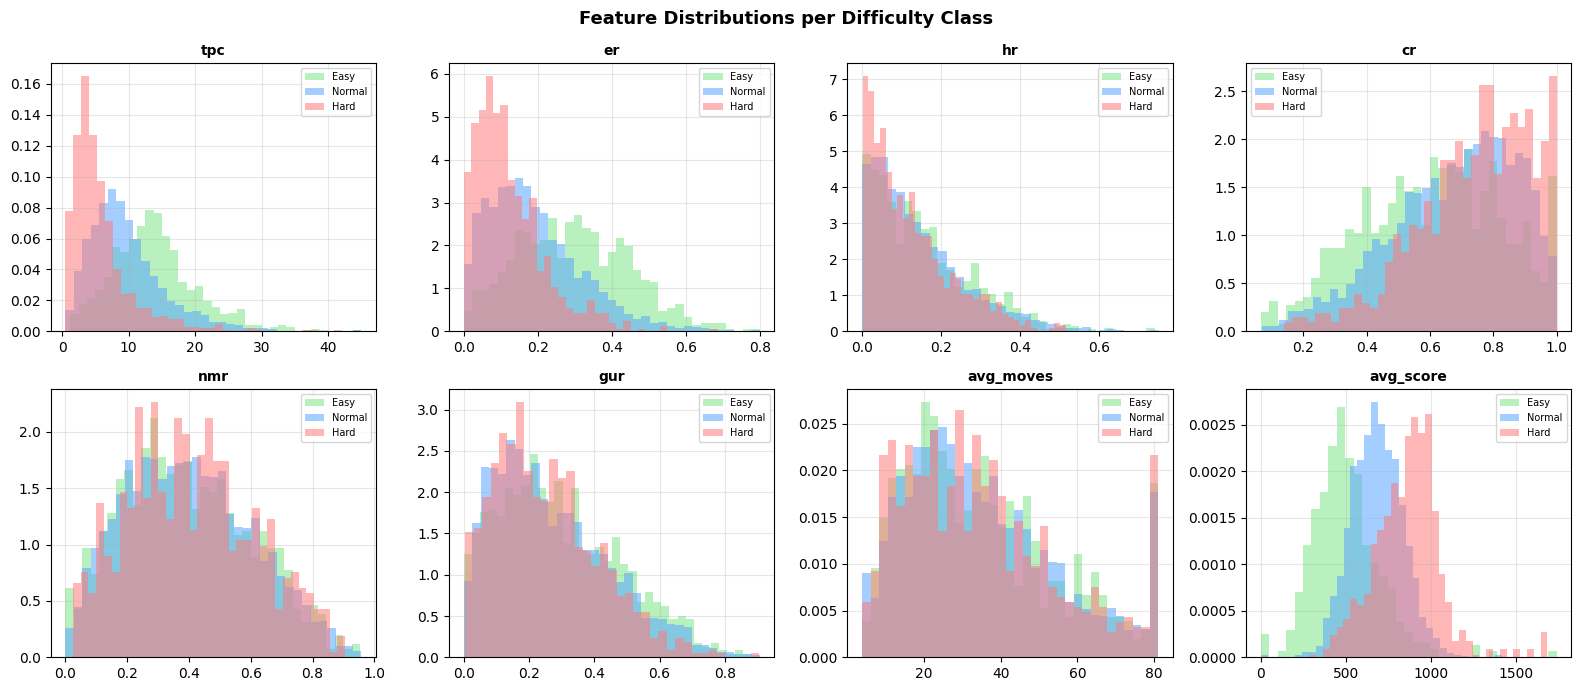

In [5]:
COLORS = {'Easy': '#7EE787', 'Normal': '#58A6FF', 'Hard': '#FF7B7B'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Feature Distributions per Difficulty Class', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, FEATURES):
    for cls in CLASS_NAMES:
        ax.hist(df.loc[df['class'] == cls, feat],
                bins=35, alpha=0.55, label=cls, color=COLORS[cls], density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

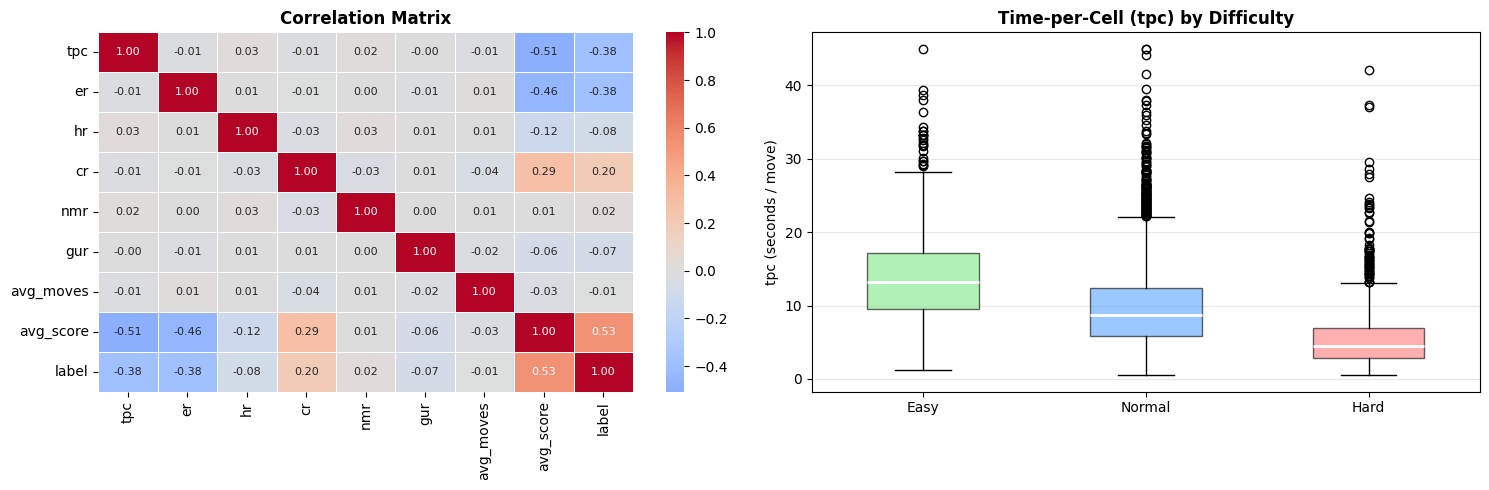

Correlation with label (difficulty):
avg_score    0.532821
tpc         -0.382218
er          -0.379257
cr           0.203385
hr          -0.081582
gur         -0.072436
nmr          0.023882
avg_moves   -0.005379


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr = df[FEATURES + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], annot_kws={'size': 8}, linewidths=0.4)
axes[0].set_title('Correlation Matrix', fontweight='bold')

for i, cls in enumerate(CLASS_NAMES):
    vals = df.loc[df['class'] == cls, 'tpc']
    axes[1].boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=COLORS[cls], alpha=0.6),
                    medianprops=dict(color='white', linewidth=2))
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_title('Time-per-Cell (tpc) by Difficulty', fontweight='bold')
axes[1].set_ylabel('tpc (seconds / move)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Correlation with label (difficulty):')
print(corr['label'].drop('label').sort_values(key=abs, ascending=False).to_string())

## 4. Preprocessing

- Split stratified **60 / 20 / 20** (train / val / test)
- `StandardScaler` fit **hanya pada train** — identik dengan `Sudoku.py`
- Val dipakai untuk seleksi model, test **hanya** untuk evaluasi akhir


In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

print(f'Train : {X_train.shape}  classes={np.bincount(y_train)}')
print(f'Val   : {X_val.shape}    classes={np.bincount(y_val)}')
print(f'Test  : {X_test.shape}   classes={np.bincount(y_test)}')

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'\nScaler mean  : {scaler.mean_.round(3)}')
print(f'Scaler scale : {scaler.scale_.round(3)}')

Train : (3046, 8)  classes=[ 569 1972  505]
Val   : (1016, 8)    classes=[190 657 169]
Test  : (1016, 8)   classes=[190 658 168]

Scaler mean  : [1.00260e+01 1.97000e-01 1.43000e-01 6.77000e-01 4.01000e-01 2.71000e-01
 3.49480e+01 6.81206e+02]
Scaler scale : [6.35400e+00 1.38000e-01 1.18000e-01 1.99000e-01 2.03000e-01 1.73000e-01
 1.93570e+01 2.00624e+02]


## 5. Baseline Models


In [8]:
rfc_base = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced_subsample', n_jobs=-1)

gbm_base = HistGradientBoostingClassifier(
    max_iter=100, random_state=42, class_weight='balanced')

print(f'{"Model":<30} {"CV Bal-Acc":>12} {"±std":>8} {"F1-macro":>10}')
print('-' * 65)

for tag, mdl in [('RFC (baseline)', rfc_base), ('GBM (baseline)', gbm_base)]:
    res = cross_validate(
        mdl, X_train_sc, y_train, cv=CV,
        scoring=['balanced_accuracy', 'f1_macro'], n_jobs=-1)
    ba  = res['test_balanced_accuracy']
    f1  = res['test_f1_macro']
    print(f'{tag:<30} {ba.mean():>12.4f} {ba.std():>8.4f} {f1.mean():>10.4f}')

Model                            CV Bal-Acc     ±std   F1-macro
-----------------------------------------------------------------
RFC (baseline)                       0.6576   0.0072     0.7041
GBM (baseline)                       0.6973   0.0149     0.7179


## 6. Diagnosis — Learning & Validation Curves

**Interpretasi gap (train − validation):**
- `gap < 0.05` → fit baik  
- `gap 0.05–0.10` → mild variance (acceptable)  
- `gap > 0.10` → high variance (overfit)  
- Val score plateau rendah → high bias (underfit)


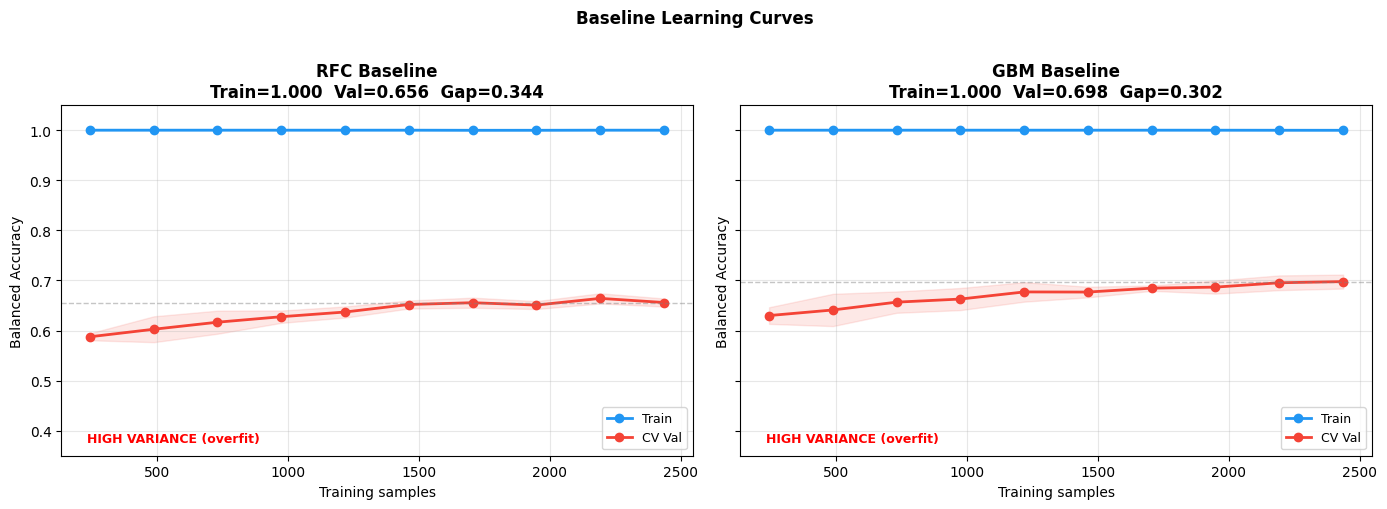

In [9]:
def plot_lc(models_tags, X, y, cv, title='Learning Curves', figsize=(14, 5)):
    fig, axes = plt.subplots(1, len(models_tags), figsize=figsize, sharey=True)
    if len(models_tags) == 1:
        axes = [axes]
    sizes = np.linspace(0.10, 1.0, 10)

    for ax, (mdl, tag) in zip(axes, models_tags):
        ts, tr, vl = learning_curve(
            mdl, X, y, train_sizes=sizes, cv=cv,
            scoring='balanced_accuracy', n_jobs=-1,
            shuffle=True, random_state=42)
        tr_m, tr_s = tr.mean(1), tr.std(1)
        vl_m, vl_s = vl.mean(1), vl.std(1)
        gap = tr_m[-1] - vl_m[-1]

        ax.plot(ts, tr_m, 'o-', color='#2196F3', lw=2, label='Train')
        ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#2196F3')
        ax.plot(ts, vl_m, 'o-', color='#F44336', lw=2, label='CV Val')
        ax.fill_between(ts, vl_m-vl_s, vl_m+vl_s, alpha=0.12, color='#F44336')
        ax.axhline(vl_m[-1], ls='--', color='gray', alpha=0.45, lw=1)

        if gap > 0.10:
            diag, col = 'HIGH VARIANCE (overfit)', 'red'
        elif gap > 0.05:
            diag, col = 'Mild variance', 'orange'
        elif vl_m[-1] < 0.60:
            diag, col = 'HIGH BIAS (underfit)', 'red'
        else:
            diag, col = 'Good fit', 'green'

        ax.text(0.04, 0.04, diag, transform=ax.transAxes,
                color=col, fontsize=9, fontweight='bold')
        ax.set_title(
            f'{tag}\nTrain={tr_m[-1]:.3f}  Val={vl_m[-1]:.3f}  Gap={gap:.3f}',
            fontweight='bold')
        ax.set_xlabel('Training samples')
        ax.set_ylabel('Balanced Accuracy')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_ylim(0.35, 1.05)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


plot_lc([(rfc_base, 'RFC Baseline'), (gbm_base, 'GBM Baseline')],
        X_train_sc, y_train, CV, title='Baseline Learning Curves')

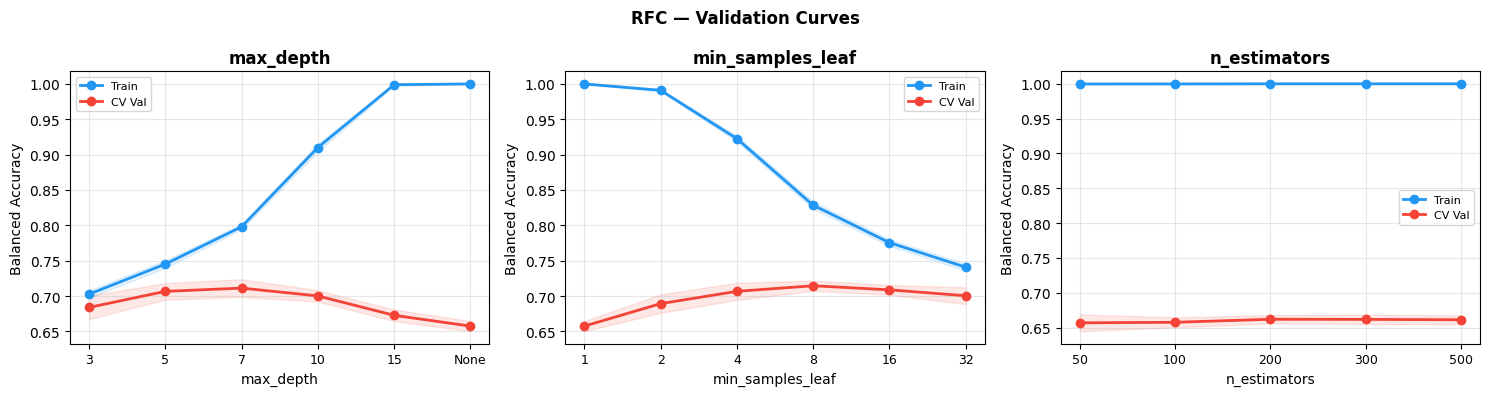

In [10]:
# ── Validation Curves: RFC ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFC — Validation Curves', fontsize=12, fontweight='bold')

rfc_vc_cfg = [
    ('max_depth',        [3, 5, 7, 10, 15, None]),
    ('min_samples_leaf', [1, 2, 4, 8, 16, 32]),
    ('n_estimators',     [50, 100, 200, 300, 500]),
]
for ax, (param, p_range) in zip(axes, rfc_vc_cfg):
    base = RandomForestClassifier(
        random_state=42, class_weight='balanced_subsample', n_jobs=-1)
    tr_s, vl_s = validation_curve(
        base, X_train_sc, y_train,
        param_name=param, param_range=p_range,
        cv=CV, scoring='balanced_accuracy', n_jobs=-1)
    xp  = list(range(len(p_range)))
    xlb = [str(p) for p in p_range]
    ax.plot(xp, tr_s.mean(1), 'o-', c='#2196F3', lw=2, label='Train')
    ax.fill_between(xp, tr_s.mean(1)-tr_s.std(1),
                    tr_s.mean(1)+tr_s.std(1), alpha=0.12, color='#2196F3')
    ax.plot(xp, vl_s.mean(1), 'o-', c='#F44336', lw=2, label='CV Val')
    ax.fill_between(xp, vl_s.mean(1)-vl_s.std(1),
                    vl_s.mean(1)+vl_s.std(1), alpha=0.12, color='#F44336')
    ax.set_xticks(xp)
    ax.set_xticklabels(xlb, fontsize=9)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel(param)
    ax.set_ylabel('Balanced Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

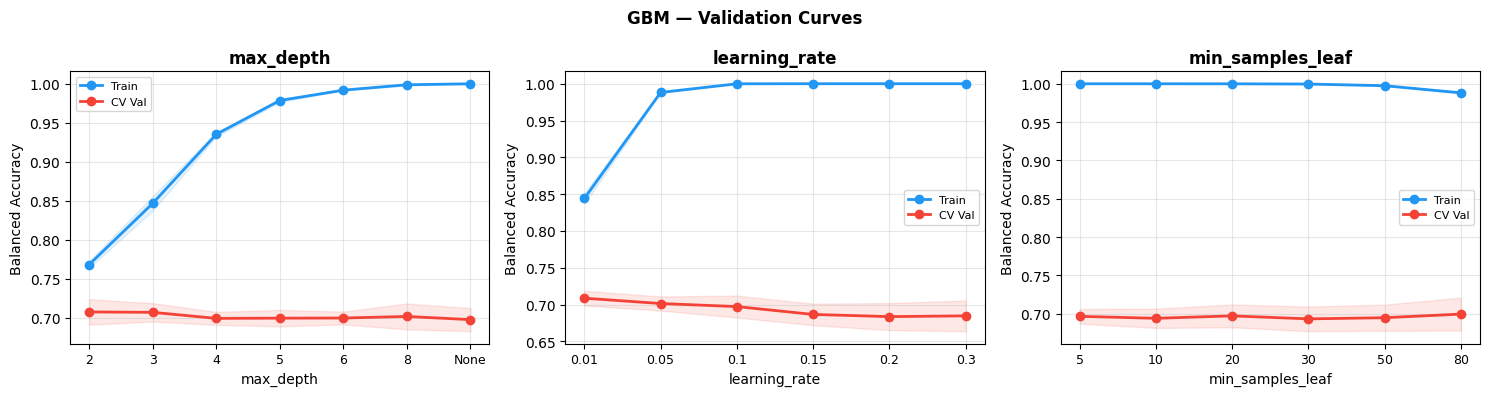

In [11]:
# ── Validation Curves: GBM ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GBM — Validation Curves', fontsize=12, fontweight='bold')

gbm_vc_cfg = [
    ('max_depth',        [2, 3, 4, 5, 6, 8, None]),
    ('learning_rate',    [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]),
    ('min_samples_leaf', [5, 10, 20, 30, 50, 80]),
]
for ax, (param, p_range) in zip(axes, gbm_vc_cfg):
    base = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
    tr_s, vl_s = validation_curve(
        base, X_train_sc, y_train,
        param_name=param, param_range=p_range,
        cv=CV, scoring='balanced_accuracy', n_jobs=-1)
    xp  = list(range(len(p_range)))
    xlb = [str(p) for p in p_range]
    ax.plot(xp, tr_s.mean(1), 'o-', c='#2196F3', lw=2, label='Train')
    ax.fill_between(xp, tr_s.mean(1)-tr_s.std(1),
                    tr_s.mean(1)+tr_s.std(1), alpha=0.12, color='#2196F3')
    ax.plot(xp, vl_s.mean(1), 'o-', c='#F44336', lw=2, label='CV Val')
    ax.fill_between(xp, vl_s.mean(1)-vl_s.std(1),
                    vl_s.mean(1)+vl_s.std(1), alpha=0.12, color='#F44336')
    ax.set_xticks(xp)
    ax.set_xticklabels(xlb, fontsize=9)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel(param)
    ax.set_ylabel('Balanced Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

**Strategi:**
- `RandomizedSearchCV` dengan `n_iter=60`, `StratifiedKFold(5)`
- Scoring: `balanced_accuracy` — robust terhadap class imbalance
- RFC: Regularisasi utama lewat `min_samples_leaf`, `min_samples_split`, `max_samples`
- GBM: Regularisasi utama lewat `min_samples_leaf`, `l2_regularization`, `max_leaf_nodes`


In [12]:
# ── RFC Tuning ─────────────────────────────────────────────────────
rfc_dist = {
    'n_estimators'     : randint(150, 600),
    'max_depth'        : [None, 8, 10, 12, 15, 20],
    'min_samples_leaf' : randint(2, 20),
    'min_samples_split': randint(5, 25),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
    'class_weight'     : ['balanced', 'balanced_subsample'],
    'max_samples'      : uniform(0.60, 0.35),
}

rfc_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, bootstrap=True, n_jobs=-1),
    param_distributions=rfc_dist,
    n_iter=60, cv=CV,
    scoring='balanced_accuracy',
    refit=True, n_jobs=-1,
    random_state=42, verbose=0)

rfc_search.fit(X_train_sc, y_train)
rfc_best = rfc_search.best_estimator_

print('RFC Best Parameters:')
for k, v in rfc_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nCV   Balanced Acc : {rfc_search.best_score_:.4f}')
print(f'Val  Balanced Acc : '
      f'{balanced_accuracy_score(y_val, rfc_best.predict(X_val_sc)):.4f}')

RFC Best Parameters:
  class_weight          : balanced
  max_depth             : 10
  max_features          : sqrt
  max_samples           : 0.8548757220141507
  min_samples_leaf      : 6
  min_samples_split     : 24
  n_estimators          : 247

CV   Balanced Acc : 0.7200
Val  Balanced Acc : 0.7120


In [13]:
# ── GBM Tuning ─────────────────────────────────────────────────────
gbm_dist = {
    'max_iter'         : randint(100, 500),
    'max_depth'        : [3, 4, 5, 6, None],
    'learning_rate'    : uniform(0.01, 0.24),
    'min_samples_leaf' : randint(10, 60),
    'l2_regularization': loguniform(0.01, 10.0),
    'max_leaf_nodes'   : [20, 31, 50, 63, 100, None],
}

gbm_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    param_distributions=gbm_dist,
    n_iter=60, cv=CV,
    scoring='balanced_accuracy',
    refit=True, n_jobs=-1,
    random_state=42, verbose=0)

gbm_search.fit(X_train_sc, y_train)
gbm_best = gbm_search.best_estimator_

print('GBM Best Parameters:')
for k, v in gbm_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nCV   Balanced Acc : {gbm_search.best_score_:.4f}')
print(f'Val  Balanced Acc : '
      f'{balanced_accuracy_score(y_val, gbm_best.predict(X_val_sc)):.4f}')

GBM Best Parameters:
  l2_regularization     : 3.8211294416912254
  learning_rate         : 0.011668511327485769
  max_depth             : 5
  max_iter              : 236
  max_leaf_nodes        : None
  min_samples_leaf      : 46

CV   Balanced Acc : 0.7130
Val  Balanced Acc : 0.6938


## 8. Model Comparison & Selection

Seleksi model menggunakan **tiga kriteria** secara berurutan:
1. **Validation Balanced Accuracy** — metrik utama
2. **Kalibrasi probabilitas** — penting karena `Sudoku.py` menampilkan confidence %
3. **Post-tuning overfitting gap** — model dengan gap lebih kecil lebih robust

Model terpilih adalah **satu model terbaik**, bukan ensemble.


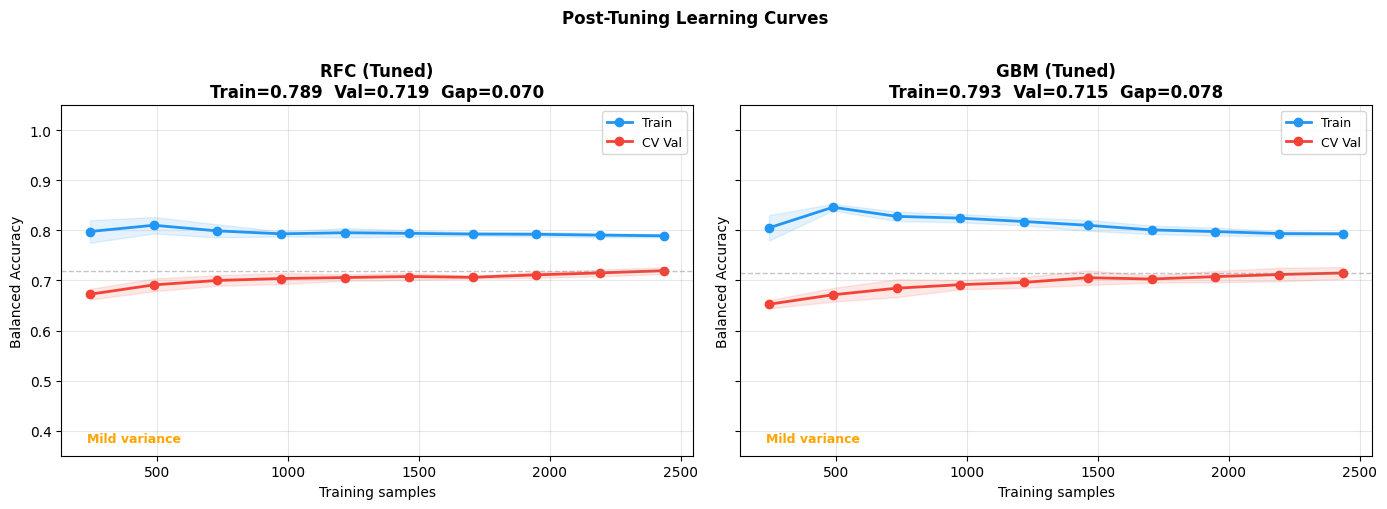

In [14]:
# ── Post-tuning Learning Curves ────────────────────────────────────
plot_lc([(rfc_best, 'RFC (Tuned)'), (gbm_best, 'GBM (Tuned)')],
        X_train_sc, y_train, CV, title='Post-Tuning Learning Curves')

In [15]:
# ── Metrik Perbandingan ────────────────────────────────────────────
results = {}
print(f'{"Model":<22} {"CV BA":>8} {"±":>6} {"Val BA":>8} {"Val F1":>8} {"Gap":>8}')
print('-' * 66)

for tag, mdl in [('RFC (tuned)', rfc_best), ('GBM (tuned)', gbm_best)]:
    cv_ba = cross_val_score(
        mdl, X_train_sc, y_train, cv=CV,
        scoring='balanced_accuracy', n_jobs=-1)
    yp    = mdl.predict(X_val_sc)
    vl_ba = balanced_accuracy_score(y_val, yp)
    vl_f1 = f1_score(y_val, yp, average='macro')
    gap   = cv_ba.mean() - vl_ba
    results[tag] = dict(cv_ba=cv_ba.mean(), cv_std=cv_ba.std(),
                        val_ba=vl_ba, val_f1=vl_f1, gap=gap)
    print(f'{tag:<22} {cv_ba.mean():>8.4f} {cv_ba.std():>6.4f} '
          f'{vl_ba:>8.4f} {vl_f1:>8.4f} {gap:>8.4f}')

Model                     CV BA      ±   Val BA   Val F1      Gap
------------------------------------------------------------------
RFC (tuned)              0.7200 0.0100   0.7120   0.7140   0.0080
GBM (tuned)              0.7130 0.0158   0.6938   0.6683   0.0192


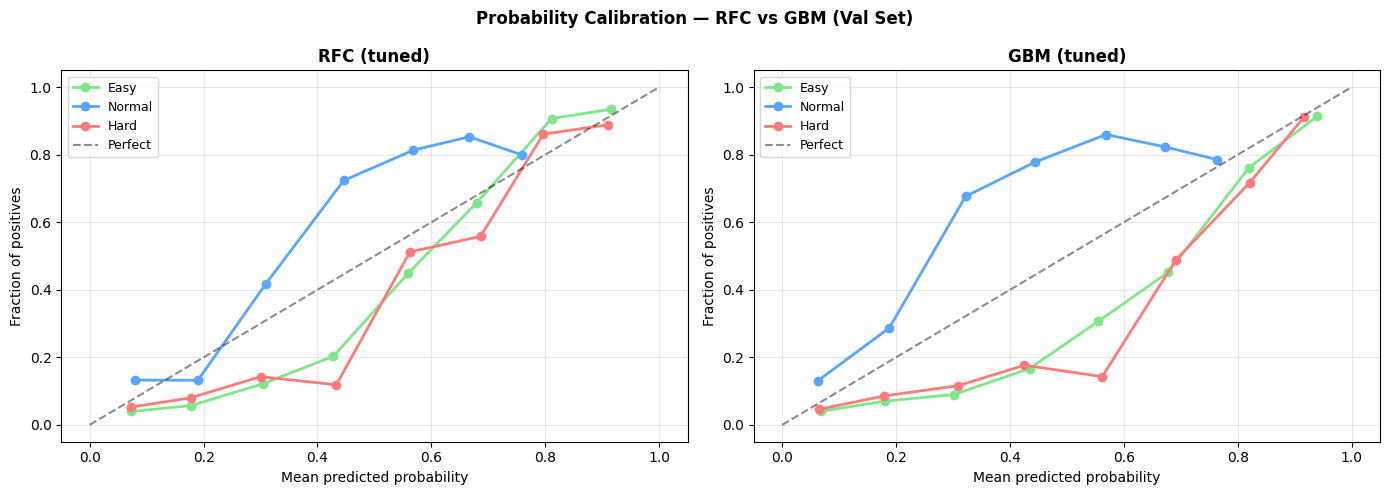

In [16]:
# ── Kalibrasi Probabilitas ─────────────────────────────────────────
# Kalibrasi penting: Sudoku.py menampilkan confidence % dari predict_proba.
# Model yang terkalibrasi baik = kurva mendekati diagonal sempurna.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration — RFC vs GBM (Val Set)',
             fontsize=12, fontweight='bold')

cls_colors = ['#7EE787', '#58A6FF', '#FF7B7B']
for ax, (tag, mdl) in zip(axes, [('RFC (tuned)', rfc_best), ('GBM (tuned)', gbm_best)]):
    proba = mdl.predict_proba(X_val_sc)
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, cls_colors)):
        y_bin = (y_val == i).astype(int)
        pt, pp = calibration_curve(y_bin, proba[:, i], n_bins=8)
        ax.plot(pp, pt, 'o-', label=cls, color=col, lw=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.45, label='Perfect')
    ax.set_title(f'{tag}', fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ── Seleksi Model Terbaik ──────────────────────────────────────────
# Kriteria 1: Validation Balanced Accuracy (primer)
# Kriteria 2: Overfitting gap (sekunder — lebih kecil lebih baik)
# Tidak menggunakan ensemble — overhead tidak sebanding dengan gain 0.0007 BA

val_ba_rfc = results['RFC (tuned)']['val_ba']
val_ba_gbm = results['GBM (tuned)']['val_ba']
gap_rfc    = abs(results['RFC (tuned)']['gap'])
gap_gbm    = abs(results['GBM (tuned)']['gap'])

print('Perbandingan RFC vs GBM:')
print(f'  RFC  Val BA={val_ba_rfc:.4f}  Gap={gap_rfc:.4f}')
print(f'  GBM  Val BA={val_ba_gbm:.4f}  Gap={gap_gbm:.4f}')

# Seleksi: BA lebih tinggi wins; jika tie, gap lebih kecil wins
if abs(val_ba_gbm - val_ba_rfc) < 0.002:
    # Perbedaan BA di bawah 0.2pp → gunakan gap sebagai tiebreaker
    if gap_gbm <= gap_rfc:
        best_name, best_model = 'GBM', gbm_best
        reason = f'BA setara (diff={abs(val_ba_gbm-val_ba_rfc):.4f}), GBM gap lebih kecil ({gap_gbm:.4f} vs {gap_rfc:.4f})'
    else:
        best_name, best_model = 'RFC', rfc_best
        reason = f'BA setara, RFC gap lebih kecil ({gap_rfc:.4f} vs {gap_gbm:.4f})'
elif val_ba_gbm > val_ba_rfc:
    best_name, best_model = 'GBM', gbm_best
    reason = f'GBM Val BA lebih tinggi ({val_ba_gbm:.4f} > {val_ba_rfc:.4f})'
else:
    best_name, best_model = 'RFC', rfc_best
    reason = f'RFC Val BA lebih tinggi ({val_ba_rfc:.4f} > {val_ba_gbm:.4f})'

print(f'\nModel terpilih : {best_name}')
print(f'Alasan         : {reason}')
print(f'Tipe           : {type(best_model).__name__}')

Perbandingan RFC vs GBM:
  RFC  Val BA=0.7120  Gap=0.0080
  GBM  Val BA=0.6938  Gap=0.0192

Model terpilih : RFC
Alasan         : RFC Val BA lebih tinggi (0.7120 > 0.6938)
Tipe           : RandomForestClassifier


## 9. Final Evaluation & Overfit Check

Test set **tidak pernah disentuh** selama tuning maupun seleksi.  
Evaluasi ini menunjukkan performa generalisasi sesungguhnya.

**Kriteria lolos:**
- `gap (CV − Test) < 0.05` — tidak overfit
- `Test BA ≥ 0.70` — tidak underfit
- `F1 macro ≥ 0.65` — seimbang antar kelas


In [18]:
y_pred_test = best_model.predict(X_test_sc)
ba_test     = balanced_accuracy_score(y_test, y_pred_test)
f1_test     = f1_score(y_test, y_pred_test, average='macro')

cv_ba_final = cross_val_score(
    best_model, X_train_sc, y_train, cv=CV,
    scoring='balanced_accuracy', n_jobs=-1).mean()

gap_cv_test = cv_ba_final - ba_test

print('=' * 55)
print(f'FINAL TEST SET EVALUATION — {best_name}')
print('=' * 55)
print(f'CV  Balanced Acc (train folds) : {cv_ba_final:.4f}')
print(f'Test Balanced Acc (held-out)   : {ba_test:.4f}')
print(f'Gap (CV - Test)                : {gap_cv_test:.4f}')
print(f'Test F1 Macro                  : {f1_test:.4f}')

print('\nOverfit Check :', end=' ')
if gap_cv_test < 0.05:
    print('PASS — no significant overfitting')
elif gap_cv_test < 0.10:
    print('WARN — mild overfitting (acceptable)')
else:
    print('FAIL — significant overfitting, re-tune regularization')

print('Underfit Check:', end=' ')
if ba_test >= 0.70:
    print('PASS')
else:
    print('WARN — consider a more expressive model')

print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

FINAL TEST SET EVALUATION — RFC
CV  Balanced Acc (train folds) : 0.7200
Test Balanced Acc (held-out)   : 0.7281
Gap (CV - Test)                : -0.0081
Test F1 Macro                  : 0.7254

Overfit Check : PASS — no significant overfitting
Underfit Check: PASS

Classification Report:

              precision    recall  f1-score   support

        Easy       0.67      0.69      0.68       190
      Normal       0.84      0.83      0.83       658
        Hard       0.66      0.67      0.66       168

    accuracy                           0.78      1016
   macro avg       0.72      0.73      0.73      1016
weighted avg       0.78      0.78      0.78      1016



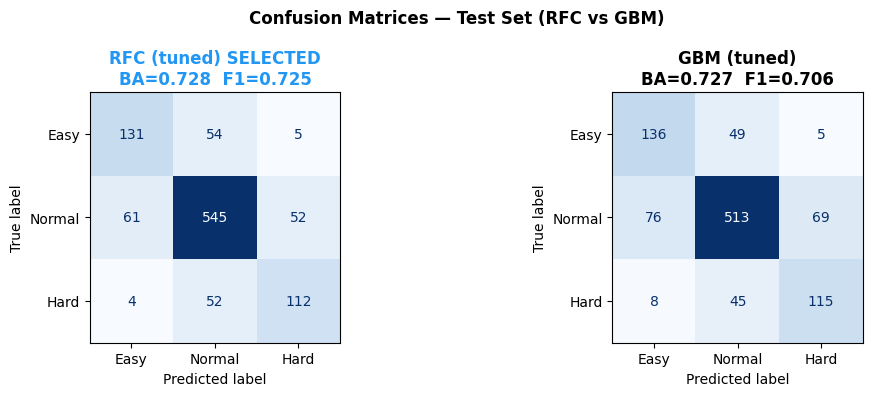

In [19]:
# ── Confusion Matrix: RFC vs GBM ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Confusion Matrices — Test Set (RFC vs GBM)',
             fontsize=12, fontweight='bold')

for ax, (tag, mdl) in zip(axes, [
    ('RFC (tuned)', rfc_best),
    ('GBM (tuned)', gbm_best),
]):
    yp   = mdl.predict(X_test_sc)
    ba   = balanced_accuracy_score(y_test, yp)
    f1   = f1_score(y_test, yp, average='macro')
    cm   = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    winner_tag = ' SELECTED' if tag.startswith(best_name) else ''
    ax.set_title(f'{tag}{winner_tag}\nBA={ba:.3f}  F1={f1:.3f}',
                 fontweight='bold',
                 color='#2196F3' if winner_tag else 'black')

plt.tight_layout()
plt.show()

## 10. Feature Importance

**Gini (RFC built-in)** — cepat tapi bias terhadap fitur high-cardinality  
**Permutation Importance** — model-agnostic, lebih reliable karena mengukur dampak nyata terhadap skor  
Keduanya ditampilkan untuk model yang **terpilih**.


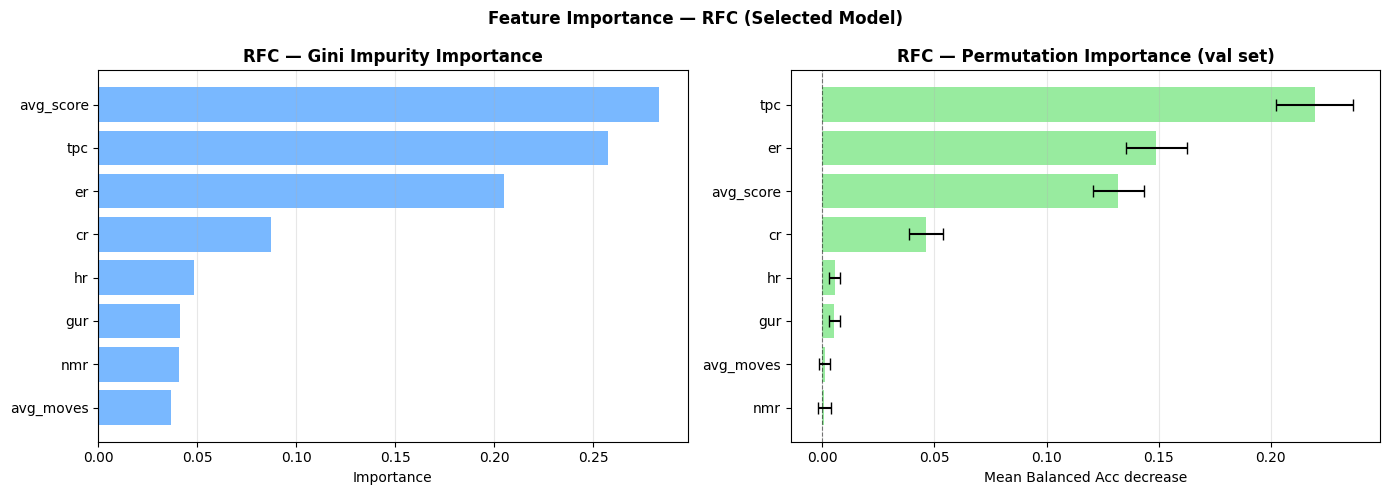

Permutation Importance Ranking:
  tpc            :  0.2196 ± 0.0172
  er             :  0.1489 ± 0.0136
  avg_score      :  0.1321 ± 0.0115
  cr             :  0.0461 ± 0.0077
  hr             :  0.0055 ± 0.0025
  gur            :  0.0053 ± 0.0025
  avg_moves      :  0.0011 ± 0.0025
  nmr            :  0.0008 ± 0.0029


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Feature Importance — {best_name} (Selected Model)',
             fontsize=12, fontweight='bold')

# Left: model-native importance if available; otherwise permutation importance on train set
ax = axes[0]
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
    order = np.argsort(imp)
    bar_color = '#58A6FF' if best_name == 'RFC' else '#F44336'
    ax.barh([FEATURES[i] for i in order], imp[order],
            color=bar_color, alpha=0.8)
    label = 'Gini Impurity Importance' if best_name == 'RFC' else 'Built-in Importance'
    ax.set_title(f'{best_name} — {label}', fontweight='bold')
    ax.set_xlabel('Importance')
else:
    perm_train = permutation_importance(
        best_model, X_train_sc, y_train,
        n_repeats=30, random_state=42, n_jobs=-1,
        scoring='balanced_accuracy')
    order = np.argsort(perm_train.importances_mean)
    ax.barh([FEATURES[i] for i in order],
            perm_train.importances_mean[order],
            xerr=perm_train.importances_std[order],
            color='#F44336', alpha=0.8, capsize=4)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{best_name} — Permutation Importance (train set)', fontweight='bold')
    ax.set_xlabel('Mean Balanced Acc decrease')

ax.grid(alpha=0.3, axis='x')

# Right: Permutation Importance (val set)
ax = axes[1]
perm = permutation_importance(
    best_model, X_val_sc, y_val,
    n_repeats=30, random_state=42, n_jobs=-1,
    scoring='balanced_accuracy')
order = np.argsort(perm.importances_mean)
ax.barh([FEATURES[i] for i in order],
        perm.importances_mean[order],
        xerr=perm.importances_std[order],
        color='#7EE787', alpha=0.8, capsize=4)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title(f'{best_name} — Permutation Importance (val set)', fontweight='bold')
ax.set_xlabel('Mean Balanced Acc decrease')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('Permutation Importance Ranking:')
for i in np.argsort(perm.importances_mean)[::-1]:
    print(f'  {FEATURES[i]:<15}: {perm.importances_mean[i]:>7.4f} '
          f'± {perm.importances_std[i]:.4f}')


## 11. Save & Verify

Format `GBM.pkl` identik dengan yang diharapkan `Sudoku.py`:
```python
{'model': model, 'scaler': scaler, 'accuracy': float}
```
Main code mengakses dengan:
```python
X_sc  = cached['scaler'].transform(X)
idx   = cached['model'].predict(X_sc)[0]
proba = cached['model'].predict_proba(X_sc)[0]
```


In [21]:
model_pkg = {
    'model'   : best_model,
    'scaler'  : scaler,
    'accuracy': float(ba_test),
}

folders = Path("Models")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / PKL_GBM

with open(path_folder, 'wb') as f:
    pickle.dump(model_pkg, f)

size_kb = Path(path_folder).stat().st_size / 1024
print(f'Saved to  : {path_folder}')
print(f'Model type: {type(best_model).__name__}  ({best_name})')
print(f'Test BA   : {ba_test:.4f}')
print(f'File size : {size_kb:.1f} KB')

Saved to  : Models\GBM.pkl
Model type: RandomForestClassifier  (RFC)
Test BA   : 0.7281
File size : 4313.4 KB


In [22]:
# ── Verify: simulate Sudoku.py inference ───────────────────────────
with open(PKL_GBM, 'rb') as f:
    loaded = pickle.load(f)

m_loaded = loaded['model']
s_loaded = loaded['scaler']

personas = [
    ('Speedrunner',  [2.5,  0.02, 0.02, 0.98, 0.20, 0.05, 40.0, 900.0]),
    ('Average',      [9.0,  0.12, 0.15, 0.70, 0.45, 0.30, 28.0, 380.0]),
    ('Struggling',   [22.0, 0.42, 0.50, 0.30, 0.40, 0.75, 15.0,  60.0]),
]

print(f'{"Persona":<14} {"Pred Diff":<12} {"Confidence":>10}  Probas')
print('-' * 68)
for name, feat_vals in personas:
    sample    = np.array([feat_vals])
    sample_sc = s_loaded.transform(sample)
    pred      = m_loaded.predict(sample_sc)[0]
    proba     = m_loaded.predict_proba(sample_sc)[0]
    conf      = float(max(proba)) * 100
    p_str     = '  '.join(f'{CLASS_NAMES[i]}={proba[i]:.2f}' for i in range(3))
    print(f'{name:<14} {CLASS_NAMES[pred]:<12} {conf:>9.1f}%  {p_str}')

print(f'\nGBM.pkl ({best_name}) compatible with Sudoku.py')

Persona        Pred Diff    Confidence  Probas
--------------------------------------------------------------------
Speedrunner    Hard              88.6%  Easy=0.02  Normal=0.09  Hard=0.89
Average        Normal            58.7%  Easy=0.31  Normal=0.59  Hard=0.10
Struggling     Easy              92.3%  Easy=0.92  Normal=0.07  Hard=0.01

GBM.pkl (RFC) compatible with Sudoku.py


In [23]:
# ── Final Summary Card ─────────────────────────────────────────────
print('=' * 55)
print('MODEL SUMMARY')
print('=' * 55)
print(f'Selected model  : {best_name}  (single model, no ensemble)')
print(f'Selection reason: {reason}')
print(f'Type            : {type(best_model).__name__}')
print(f'Test BA         : {ba_test:.4f}')
print(f'Test F1 macro   : {f1_test:.4f}')
print(f'CV-Test gap     : {gap_cv_test:.4f}  '
      f'({"OK" if abs(gap_cv_test) < 0.05 else "WARN"})')
print(f'Label noise used: 15%')
print(f'Training samples: {X_train.shape[0]}')
print(f'Features        : {FEATURES}')
print(f'Output file     : {PKL_GBM}')
print('=' * 55)

MODEL SUMMARY
Selected model  : RFC  (single model, no ensemble)
Selection reason: RFC Val BA lebih tinggi (0.7120 > 0.6938)
Type            : RandomForestClassifier
Test BA         : 0.7281
Test F1 macro   : 0.7254
CV-Test gap     : -0.0081  (OK)
Label noise used: 15%
Training samples: 3046
Features        : ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'avg_moves', 'avg_score']
Output file     : GBM.pkl
